In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

In [2]:
FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root"
TREE_PATH = "events/full/selected"
BRANCH    = "GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi"

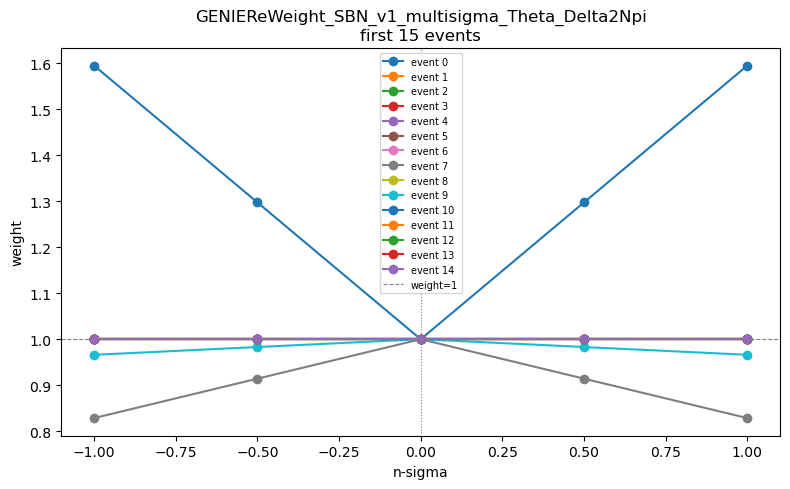

In [10]:
N_EVENTS  = 15
with uproot.open(FILE) as f:
    tree = f[TREE_PATH]
    data = tree[BRANCH].array(library="np", entry_stop=N_EVENTS)

fig, ax = plt.subplots(figsize=(8, 5))

for i, clones_array in enumerate(data):
    # Each entry is a TClonesArray — get the first (and only) TGraph inside it
    graph = clones_array[0]
    x = np.array(graph.member("fX"))
    y = np.array(graph.member("fY"))
    ax.plot(x, y, marker='o', label=f"event {i}")

ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label="weight=1")
ax.axvline(0.0, color='gray', linestyle=':',  linewidth=0.8)
ax.set_xlabel("n-sigma")
ax.set_ylabel("weight")
ax.set_title("GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi\nfirst 15 events")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

In [12]:
import uproot

FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/NuMI_CV_flat_cafs_2_00.root"

def print_tree(obj, indent=0):
    prefix = "  " * indent
    for key in obj.keys():
        item = obj[key]
        classname = item.classname if hasattr(item, 'classname') else type(item).__name__
        print(f"{prefix}├── {key}  [{classname}]")
        # Recurse into directories and trees
        if hasattr(item, 'keys'):
            try:
                print_tree(item, indent + 1)
            except Exception as e:
                print(f"{prefix}    (could not descend: {e})")

with uproot.open(FILE) as f:
    print(f"File: {FILE}\n")
    print("Contents:")
    print_tree(f)
    print()

    # Also print any TTrees found with their branches
    # print("=" * 60)
    # print("TTrees and their branches:")
    # print("=" * 60)
    # for key in f.keys(recursive=True):
    #     obj = f[key]
    #     if isinstance(obj, uproot.behaviors.TTree.TTree):
    #         print(f"\n[TTree] {key}  ({obj.num_entries} entries)")
    #         for branch in obj.keys():
    #             dtype = obj[branch].typename if hasattr(obj[branch], 'typename') else '?'
    #             print(f"  - {branch}  [{dtype}]")

File: /Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/NuMI_CV_flat_cafs_2_00.root

Contents:
├── recTree;1  [TTree]
  ├── rec.crt_hits..length  [TBranch]
  ├── rec.crt_hits.pe  [TBranch]
  ├── rec.crt_hits.plane  [TBranch]
  ├── rec.crt_hits.position.x  [TBranch]
  ├── rec.crt_hits.position.y  [TBranch]
  ├── rec.crt_hits.position.z  [TBranch]
  ├── rec.crt_hits.position_err.x  [TBranch]
  ├── rec.crt_hits.position_err.y  [TBranch]
  ├── rec.crt_hits.position_err.z  [TBranch]
  ├── rec.crt_hits.t0  [TBranch]
  ├── rec.crt_hits.t1  [TBranch]
  ├── rec.crt_hits.time  [TBranch]
  ├── rec.crt_spacepoints..length  [TBranch]
  ├── rec.crt_spacepoints.complete  [TBranch]
  ├── rec.crt_spacepoints.pe  [TBranch]
  ├── rec.crt_spacepoints.position.x  [TBranch]
  ├── rec.crt_spacepoints.position.y  [TBranch]
  ├── rec.crt_spacepoints.position.z  [TBranch]
  ├── rec.crt_spacepoints

In [13]:
import sqlite3
import pandas as pd

FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/NuMI_nu.db"

conn = sqlite3.connect(FILE)
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables found:")
for t in tables:
    print(f"  {t[0]}")

print()

# For each table, show schema and first few rows
for (table_name,) in tables:
    print("=" * 60)
    print(f"Table: {table_name}")

    # Column info
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    print("Columns:")
    for col in columns:
        print(f"  {col[1]}  [{col[2]}]")

    # Row count
    cursor.execute(f"SELECT COUNT(*) FROM {table_name};")
    count = cursor.fetchone()[0]
    print(f"Rows: {count}")

    # Preview
    print("Preview (first 3 rows):")
    df = pd.read_sql_query(f"SELECT * FROM {table_name} LIMIT 3", conn)
    print(df.to_string())
    print()

conn.close()

Tables found:
  my_table

Table: my_table
Columns:
  id  [INTEGER]
  H5_File  [TEXT]
  CAF_File  [TEXT]
  Event  [INTEGER]
  Subrun  [INTEGER]
  Run  [INTEGER]
  Energy  [REAL]
Rows: 207662
Preview (first 3 rows):
   id                                                                        H5_File                                                                                 CAF_File  Event  Subrun  Run    Energy
0   1  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_spine.h5  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_caf.root.flat.root      2       0    1  4.667109
1   2  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_spine.h5  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_caf.root.flat.root      2       0    1  1.118558
2   3  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_spine.h5  larcv_mc_20250609_041747_640706-de1c1bd3-7a49-4316-967c-19326eedd617_caf.root.flat.root 